# Country-Level Longer-Term Forecasting of First-Time Asylum Applications

*A time-series analysis and forecasting exercise using Italy monthly Eurostat data*

This notebook uses monthly first-time asylum application data for Italy to demonstrate a longer-term country-level forecasting workflow.

The purpose is demonstrative and illustrative. The notebook is not an operational forecast product, and it does not attempt to explain the full political, legal, administrative, or structural dynamics behind asylum applications in Italy. Instead, it shows how a real administrative time series can be prepared, explored, split into training and test periods, modelled with transparent time-series methods, and interpreted with appropriate caution.

The target series is **monthly first-time asylum applications**. This brings in some caveats. Asylum applications are administrative events. They are not the same as regular or irregular entries, border arrivals, total displacement movements, or the number of people in need of protection at any given time. First-time applications may be affected by access to the asylum procedure, border management, administrative capacity, policy changes, onward movement, and wider dynamics in a country's asylum system or in countries of origin. They may also be affected by changes in the legal circumstances of certain individuals or groups of people.

For that reason, the forecasts in this notebook should be read as model-based projections of an administrative series, not as direct predictions of future arrivals or the volume of international protection needs.

# Part I - Understanding the time series

## 1. Setup


In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose


## 2. Load prepared monthly series

The public notebook uses a cleaned monthly CSV derived from a locally downloaded Eurostat Excel file.

The original Excel file had countries as rows and monthly values as columns, with monthly date columns alternating with status or blank columns. During preparation, the Italy row was selected, monthly columns were parsed, Eurostat missing markers were converted, and incomplete months were excluded.

The modelling series used here runs from **January 2008 to February 2026**. The incomplete months **March 2026** and **April 2026** are not imputed and are not included.


In [24]:
data_path_candidates = [
    Path("data/processed/italy_first_time_asylum_monthly.csv"),
    Path("../../data/processed/italy_first_time_asylum_monthly.csv"),
]
data_path = next(path for path in data_path_candidates if path.exists())

applications = (
    pd.read_csv(data_path, parse_dates=["date"])
    .sort_values("date")
    .reset_index(drop=True)
)

applications_display = applications.rename(
    columns={"date": "Month", "applications": "First-time applications"}
)
applications_display.head()


,Month,First-time applications
0,2008-01-01,1170
1,2008-02-01,1105
2,2008-03-01,1800
3,2008-04-01,1780
4,2008-05-01,2850


In [25]:
applications_display.tail()


,Month,First-time applications
213,2025-10-01,12650
214,2025-11-01,12195
215,2025-12-01,9985
216,2026-01-01,10660
217,2026-02-01,10560


Before plotting the series, we check the basic structure of the data.


In [26]:
summary_table = pd.DataFrame(
    {
        "Measure": [
            "Start date",
            "End date",
            "Number of months",
            "Total applications",
            "Mean monthly applications",
            "Median monthly applications",
            "Minimum monthly applications",
            "Maximum monthly applications",
            "Missing values",
        ],
        "Value": [
            applications["date"].min().strftime("%B %Y"),
            applications["date"].max().strftime("%B %Y"),
            len(applications),
            f"{applications['applications'].sum():,.0f}",
            f"{applications['applications'].mean():,.1f}",
            f"{applications['applications'].median():,.1f}",
            f"{applications['applications'].min():,.0f}",
            f"{applications['applications'].max():,.0f}",
            int(applications.isna().sum().sum()),
        ],
    }
)

summary_table


,Measure,Value
0,Start date,January 2008
1,End date,February 2026
2,Number of months,218
3,Total applications,"1,196,610"
4,Mean monthly applications,"5,489.0"
5,Median monthly applications,"4,147.5"
6,Minimum monthly applications,120
7,Maximum monthly applications,"15,115"
8,Missing values,0


The series contains monthly counts of first-time asylum applications in Italy. The values are non-negative integer counts. The date range and missing-value checks confirm that the processed file is ready for exploratory time-series analysis.

## 3. Exploratory time-series analysis

We start by plotting the raw monthly series.


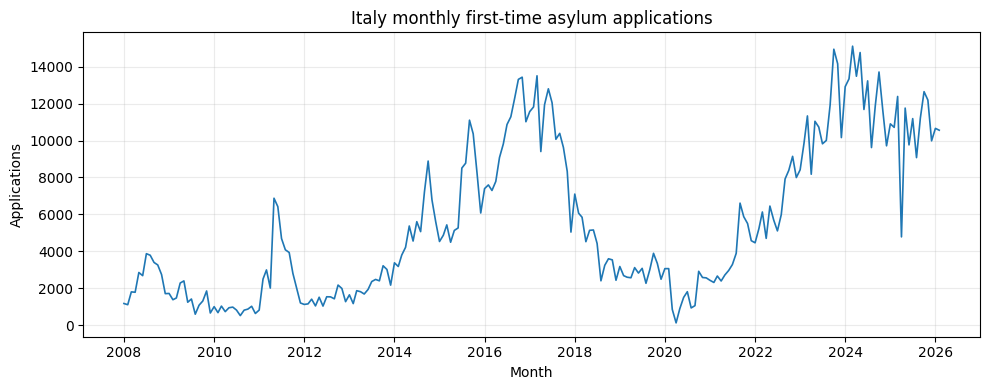

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    applications["date"],
    applications["applications"],
    linewidth=1.2,
)
ax.set_title("Italy monthly first-time asylum applications")
ax.set_xlabel("Month")
ax.set_ylabel("Applications")
ax.grid(alpha=0.25)
fig.tight_layout()


The raw series shows substantial variation over time. Some periods have relatively low monthly application counts, while others show much higher pressure. This is expected for an asylum application series: the observed counts can respond to conflict dynamics, route dynamics, access to territory and procedures, policy changes, registration practices, and administrative capacity.

The raw monthly pattern is useful, but it is also noisy. To make the longer movement easier to see, we add a 12-month rolling average.


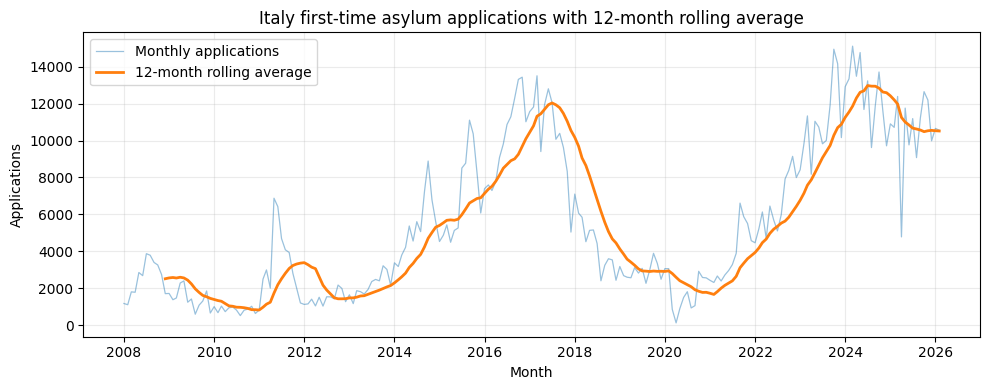

In [28]:
applications_with_rolling = applications.assign(
    rolling_12_month_average=applications["applications"].rolling(12).mean()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    applications_with_rolling["date"],
    applications_with_rolling["applications"],
    linewidth=0.9,
    alpha=0.45,
    label="Monthly applications",
)
ax.plot(
    applications_with_rolling["date"],
    applications_with_rolling["rolling_12_month_average"],
    linewidth=2.0,
    label="12-month rolling average",
)
ax.set_title("Italy first-time asylum applications with 12-month rolling average")
ax.set_xlabel("Month")
ax.set_ylabel("Applications")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()


The 12-month rolling average smooths short-term month-to-month variation and makes broader phases more visible. It does not remove the underlying uncertainty or explain the causes of change. It simply helps separate longer movements from monthly fluctuation.

For an annual view, we aggregate the monthly counts by calendar year.


In [29]:
annual_applications = (
    applications.assign(year=applications["date"].dt.year)
    .groupby("year", as_index=False)["applications"]
    .sum()
    .rename(columns={"year": "Year", "applications": "Total applications"})
)

annual_applications


,Year,Total applications
0,2008,30140
1,2009,17370
2,2010,10005
3,2011,40300
4,2012,17170
5,2013,25725
6,2014,63660
7,2015,82790
8,2016,121190
9,2017,126550


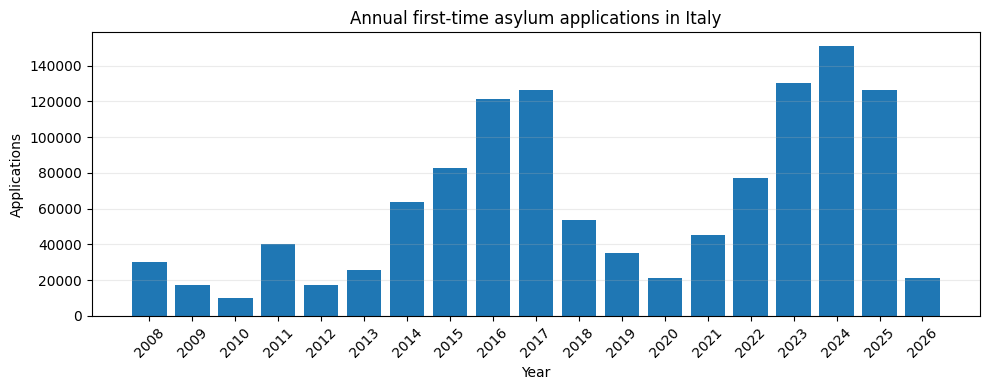

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    annual_applications["Year"].astype(str),
    annual_applications["Total applications"],
)
ax.set_title("Annual first-time asylum applications in Italy")
ax.set_xlabel("Year")
ax.set_ylabel("Applications")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()


The annual summary gives a clearer sense of scale. It also shows why a simple average is unlikely to be enough for forecasting. The series includes quieter years, higher-pressure years, and periods where the level changes substantially.

At this stage, the main lesson is descriptive: the series is not stable around one constant level. This is why the rest of the notebook moves from exploration to model-based forecasting. We will first compare simple baseline forecasts, then fit SARIMA models that account for time dependence and seasonality, and finally test whether a SARIMAX model with descriptive exogenous event-period indicators adds value.

Before doing that, we need an evaluation design. In forecasting, it is not enough to fit a model to all available observations and inspect how well it describes the past. We need to ask whether the model can make useful predictions for observations it has not seen. The next part therefore defines a training period and a test period. The training period will be used to inspect the time-series structure and fit the models; the test period will be held back so that the baselines, SARIMA models, and SARIMAX model can be evaluated against later observations.


# Part II - Creating an evaluation framework


## 4. Train/test split

The previous section showed that the application series is not stable around one constant level. The next step is to move from description to forecasting.

Before fitting models, we need an evaluation design. In a time-series setting, this means separating earlier observations from later observations. The earlier period is used for inspection and model fitting. The later period is held back and treated as future data.

This notebook uses a chronological train/test split:

- training period: January 2008 to February 2023;
- test period: March 2023 to February 2026.

The test period covers 36 months, or three full seasonal cycles. This gives us a held-out period for comparing simple baselines, SARIMA models, and later SARIMAX models against observations that were not used during fitting.


In [31]:
train_start = pd.Timestamp("2008-01-01")
train_end = pd.Timestamp("2023-02-01")
test_start = pd.Timestamp("2023-03-01")
test_end = pd.Timestamp("2026-02-01")

train = applications.loc[
    applications["date"].between(train_start, train_end)
].copy()
test = applications.loc[
    applications["date"].between(test_start, test_end)
].copy()

assert train["date"].min() == train_start
assert train["date"].max() == train_end
assert test["date"].min() == test_start
assert test["date"].max() == test_end
assert len(test) == 36

split_summary = pd.DataFrame(
    {
        "Period": ["Training", "Test"],
        "Start": [
            train["date"].min().strftime("%Y-%m"),
            test["date"].min().strftime("%Y-%m"),
        ],
        "End": [
            train["date"].max().strftime("%Y-%m"),
            test["date"].max().strftime("%Y-%m"),
        ],
        "Number of months": [len(train), len(test)],
        "Total applications": [
            int(train["applications"].sum()),
            int(test["applications"].sum()),
        ],
        "Mean monthly applications": [
            round(train["applications"].mean(), 1),
            round(test["applications"].mean(), 1),
        ],
    }
)

split_summary


,Period,Start,End,Number of months,Total applications,Mean monthly applications
0,Training,2008-01,2023-02,182,785325,4315.0
1,Test,2023-03,2026-02,36,411285,11424.6


The split is shown visually below. The vertical line marks the boundary between the training period and the held-out test period.


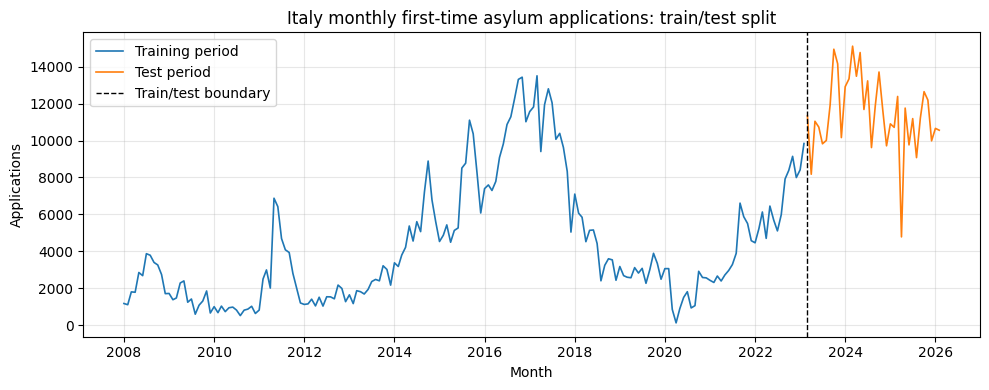

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    train["date"],
    train["applications"],
    label="Training period",
    linewidth=1.2,
)
ax.plot(
    test["date"],
    test["applications"],
    label="Test period",
    linewidth=1.2,
)
ax.axvline(
    test_start,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Train/test boundary",
)
ax.set_title("Italy monthly first-time asylum applications: train/test split")
ax.set_xlabel("Month")
ax.set_ylabel("Applications")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


## 5. Seasonal decomposition on the training data only

Before fitting forecasting models, it is useful to inspect the structure of the training series.

Seasonal decomposition separates a time series into three broad components:

- a trend component, which shows slower-moving changes in the level of the series;
- a seasonal component, which shows recurring within-year patterns;
- a residual or irregular component, which is what remains after the trend and seasonal pattern are removed.

The decomposition below is run on the training data only. This is important: the test period is supposed to represent future observations, so it should not be used to inspect or tune the model before evaluation.

The decomposition is descriptive. It is not yet a forecast model.


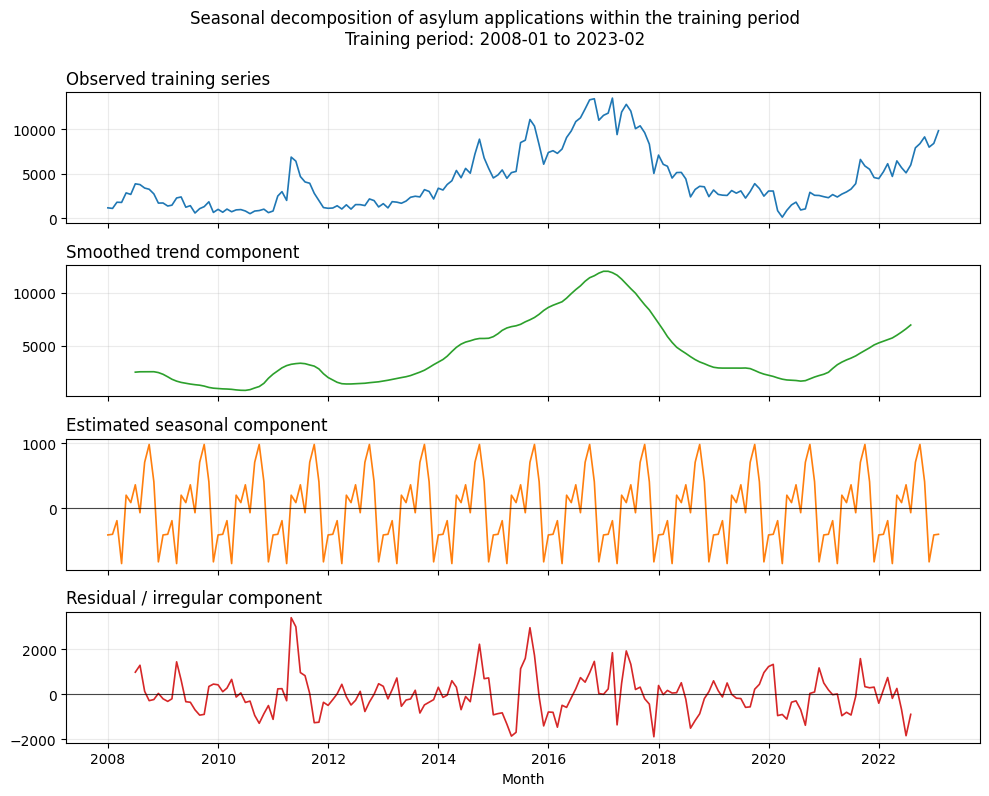

In [33]:
training_series = train.set_index("date")["applications"].asfreq("MS")

decomposition = seasonal_decompose(
    training_series,
    model="additive",
    period=12,
)

decomposition_df = pd.DataFrame(
    {
        "observed": decomposition.observed,
        "trend": decomposition.trend,
        "seasonal": decomposition.seasonal,
        "residual": decomposition.resid,
    }
)

fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
fig.suptitle(
    "Seasonal decomposition of asylum applications within the training period\n"
    "Training period: 2008-01 to 2023-02",
    y=0.99,
)

components = [
    ("observed", "Observed training series", "#1f77b4"),
    ("trend", "Smoothed trend component", "#2ca02c"),
    ("seasonal", "Estimated seasonal component", "#ff7f0e"),
    ("residual", "Residual / irregular component", "#d62728"),
]

for ax, (column, title, color) in zip(axes, components):
    ax.plot(
        decomposition_df.index,
        decomposition_df[column],
        color=color,
        linewidth=1.2,
    )
    ax.set_title(title, loc="left")
    ax.grid(alpha=0.25)

axes[2].axhline(0, color="black", linewidth=0.8, alpha=0.7)
axes[3].axhline(0, color="black", linewidth=0.8, alpha=0.7)
axes[-1].set_xlabel("Month")
fig.tight_layout()
plt.show()


The decomposition gives a useful first view of the training series, but it should be interpreted cautiously.

The trend component shows large changes in the underlying level of applications over time. It is relatively low in the early years, rises substantially through the mid-2010s, reaches its highest level around 2016-2017, then declines before rising again toward the end of the training period. This confirms that the training series is not stable around one long-term average.

A recurring seasonal pattern is visible. The seasonal component suggests that some months tend to sit above or below the average within a year. This may be consistent with seasonal route, mobility, access, or administrative patterns, but the decomposition itself does not identify the cause. It only shows that recurring within-year variation is present in the training data. This supports the use of seasonal forecasting approaches later in the notebook.

At the same time, the residual component still contains substantial irregular variation, including large positive and negative deviations. This means that trend and seasonality do not explain all of the movement in the series. The forecasting task is therefore not only about estimating a seasonal pattern; it also has to deal with structural changes and irregular shocks.

The next step is to compare simple baseline forecasts. These baselines give us a reference point before fitting SARIMA or SARIMAX models.
